In [3]:
import csv
import numpy as np
from analysis import *
import sys
#import basic libraries

import os
import math
import numpy.linalg as npla
import scipy
from scipy import sparse
from scipy import linalg
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt 
from matplotlib import cm
import matplotlib.mlab as mlab
from mpl_toolkits.mplot3d import axes3d
#%matplotlib tk
import operator
#import datashader as ds
#from datashader.mpl_ext import dsshow
import mpl_scatter_density
from matplotlib.colors import LinearSegmentedColormap

# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '/home/yw180/place/analysis/Python_code/')
from project_data_analysis import pixels_per_project, Create_Array
input_file_proj_22 = "/home/yw180/place/data_2022/sorted_tile_placements_proj.csv"
input_file_proj_23 = "/home/yw180/place/data_2022/sorted_tile_placements_proj.csv"

In [4]:
from matplotlib.ticker import ScalarFormatter
#Inverse cumulative density funcition

%matplotlib inline

def plot_updates_vs_pixels(X, Y, output_file_name, col, lab):
    white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)
#    xy = np.vstack([X,Y])
#    z = gaussian_kde(xy)(xy)
#    idx = z.argsort()
#    x, y, z = X[idx], Y[idx], z[idx]
    plt.clf()
    fig = plt.figure(figsize=(4,3))
    ax = plt.subplot(111,projection='scatter_density')    
    density = ax.scatter_density(X, Y, cmap=white_viridis)
    fig.colorbar(density, label='Number of points per pixel')
    logx = np.log(X)
    logy = np.log(Y)
    coeffs = np.polyfit(logx,logy,1)
    poly = np.poly1d(coeffs)
    yfit = lambda X: np.exp(poly(np.log(X)))
    la = r"$y = e^{%s} x^{%s}$" % (round(coeffs[1],2), round(coeffs[0], 2))
    plt.loglog(np.unique(X),yfit(np.unique(X)), color='red', label = la) 
    plt.scatter(X, Y, s=4)
    ax.axline((1, 1),  (10, 10), color="blue", linestyle=":")

    ax.set_ylabel('median updates', fontsize=15)
    #ax.tick_params(labelsize=10)
    ax.set_xlabel('coalition size', fontsize=15)
    ax.set_xscale('log')
#     ax.set_yscale('log')
#     ax.set_xlim([1,10**7])
#     ax.set_ylim([1,10**2])
#     ax.set_xticks(logx)
#     ax.set_aspect('equal', 'box')
    ax.legend(loc = 'upper right')
    ax.grid()
#     plt.axis('square')
    
#     plt.savefig(output_file_name, dpi=300, bbox_inches='tight')
    return coeffs[0]


In [5]:
def pixels_per_project(input_file_proj, projects_to_remove):
    '''
        Given input file with project assignments (ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color)
        computes the number of pixels per project. Some projects might be removed from the analysis.
    '''
    pixels_per_proj = {}

    with open(input_file_proj,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)

        for r in reader:
            #ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color
            proj = r[5]
            pixel = int(r[6])

            if proj not in projects_to_remove and pixel == 1:
                if proj in pixels_per_proj:
                    pixels_per_proj[proj] = pixels_per_proj[proj] + 1
                else:
                    pixels_per_proj[proj] = 1

    return pixels_per_proj

In [6]:
def user_per_project_on_final(input_file_proj):
    '''
        Given input file with project assignments (ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color)
        computes the number of pixels per project. Some projects might be removed from the analysis.
    '''
    users_per_proj = {}

    with open(input_file_proj,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)

        for r in reader:
            #ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color
            proj = r[5]
            user = r[1]
            pixel = int(r[6])

            if pixel == 1:
                if proj in users_per_proj:
                    users_per_proj[proj].add(user)
                else:
                    users_per_proj[proj] = {user}
    users_per_proj = {key: len(val) for key, val in users_per_proj.items()}
    return users_per_proj

In [7]:
def agreeing_user_per_proj(input_file_proj):
    '''
        Given input file with project assignments (ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color)
        computes the number of pixels per project. Some projects might be removed from the analysis.
    '''
    users_per_proj = {}

    with open(input_file_proj,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)

        for r in reader:
            #ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color
            proj = r[5]
            user = r[1]
            pixel_color = int(r[7])
            proj_smallest = int(r[8])
            x = int(r[2])
            y = int(r[3])

            if pixel_color and proj_smallest:
                if proj in users_per_proj:
                    users_per_proj[proj].add(user)
                else:
                    users_per_proj[proj] = {user}
    users_per_proj = {key: len(val) for key, val in users_per_proj.items()}
    return users_per_proj

In [8]:
def Create_Array(Dict_1,Dict_2):
    '''
        Simple function to create arrays from two dictionaries with same project keys. 
    '''
    array_len = min(len(Dict_2), len(Dict_1))
    X = list()
    Y = list()
    for p in Dict_1.keys():
        if p in Dict_2.keys():
            X.append(Dict_1[p])
            Y.append(Dict_2[p]) 
    return np.array(X),np.array(Y)

In [9]:
def calculate_coordination_cost(color_canv, input_file_proj, pixels_per_project, year):
    curr_canv = np.array(-1 * np.ones((len(color_canv), len(color_canv[0]))), dtype='str')
    proj_cost = dict()
    proj_total = dict()
    proj_proportion = dict()
    with open(input_file_proj,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)

        for r in reader:
            #ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color
            if year == 2017:
                t = int(r[0]) / 1000
            else:
                t = int(r[0])
            proj = r[5]
            user = r[1]
            x = int(r[2])
            y = int(r[3])
            color = r[4]
            smallest = int(r[8])
            if not smallest:
                continue
            prev_color = curr_canv[y,x]
            curr_canv[y,x] = color
            final_color = color_canv[y,x]
            if color == final_color and proj not in proj_cost:
                proj_cost[proj] = 0
                proj_total[proj] = 0
            if color == final_color:
                proj_total[proj] += 1
                if color == prev_color:
                    proj_cost[proj] += 1
    for proj in proj_cost:
        proj_proportion[proj] = proj_cost[proj] / proj_total[proj]
    return proj_proportion, proj_cost, proj_total

In [10]:
def agreeing_updates_proj(input_file_proj):
    proj_updates = dict()
    with open(input_file_proj,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)

        for r in reader:
            #ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color,proj_smallest
            proj = r[5]
            user = r[1]
            x = int(r[2])
            y = int(r[3])
            color = r[4]
            pixel_color = int(r[7])
            smallest = int(r[8])   
            if pixel_color and smallest:
                if proj in proj_updates:
                    proj_updates[proj] += 1
                else:
                    proj_updates[proj] = 1
    return proj_updates

In [11]:
def user_coalition_size_updates(input_file_proj,users_per_proj):
    user_coal = dict()
    user_update = dict()
    with open(input_file_proj,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)
        for r in reader:
            proj = r[5]
            user = r[1]
            x = int(r[2])
            y = int(r[3])
            color = r[4]
            pixel_color = int(r[7])
            smallest = int(r[8])
            if smallest and pixel_color:
                if (user, proj) not in user_coal:
                    user_coal[(user, proj)] = users_per_proj[proj]
                    user_update[(user, proj)] = 1
                else:
                    user_update[(user, proj)] += 1
    return user_coal, user_update

In [12]:
input_file_proj_17 = "/scratch/yw180/place/data/tile_placements_proj_1.csv"
project_to_remove = {}
# Computing number of pixels per project
#Only pixels (final) are considered.
pixels_proj = pixels_per_project(input_file_proj_17, project_to_remove)
# pixels_proj_17 = {int(key): val for key, val in pixels_proj_17.items()}
users_proj = user_per_project_on_final(input_file_proj_17)
for key in users_proj:
    if users_proj[key] == 0:
        del users_proj[key]

# Agreeing user per pixel

In [13]:
def build_final_label(input_file_proj,width,height):
    canv_label = np.array(np.zeros((height, width)),dtype='str')
    canv_color = np.array(np.zeros((height,width)), dtype='str')
    with open(input_file_proj,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)
        max_x = 0
        max_y = 0
        min_x = 0
        min_y = 0
        for r in reader:
            #ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color
            proj = r[5]
            user = r[1]
            x = int(r[2])
            y = int(r[3])
            color = r[4]
            pixel = int(r[6])
            if max_x < x:
                max_x = x
            if max_y < y:
                max_y = y
            if min_x > x:
                min_x = x
            if min_y > y:
                min_y = h
            if pixel == 1:
                canv_label[y,x] = proj
                canv_color[y,x] = color
        print("max_x", max_x)
        print("max_y", max_y)
        print("min_x", min_x)
        print("min_y", min_y)
    return canv_label, canv_color

In [14]:
def updates_coalition_median(user_update):
    coalition_update = dict()
    for key in user_update:
        proj = key[1]
        if proj not in user_update:
            coalition_update[proj] = [user_update[key]]
        else:
            coalition_update[proj].append(user_update[key])
    coalition_median = dict()
    for key in coalition_update:
        med = np.median(np.array(coalition_update[key]))
        coalition_median[key] = med
    return coalition_median

In [15]:
# return the probability of observing users with at least 1, 2, 3 updates
def prob_coalition(user_coalition,a_users_proj):
    prob_1 = dict()
    prob_2 = dict()
    prob_3 = dict()
    size_up = dict()
    for key in user_coalition:
        proj = key[1]
        size = a_users_proj[key[1]]
        if size not in size_up:
            size_up[size] = dict()
            size_up[size][proj] = list()
        if proj not in size_up[size]:
            size_up[size][proj] = list()
        size_up[size][proj].append(user_coalition[key])
    for key in size_up:
        for proj in size_up[key]:
            size_up[key][proj] = np.array(size_up[key][proj])
            count_1 = np.sum(size_up[key][proj] >= 1)
            count_2 = np.sum(size_up[key][proj] >= 2)
            count_3 = np.sum(size_up[key][proj] >= 10)
            if key not in prob_1:
                prob_1[key] = list()
                prob_2[key] = list()
                prob_3[key] = list()
            prob_1[key].append(count_1/len(size_up[key][proj]))
            prob_2[key].append(count_2/len(size_up[key][proj]))
            prob_3[key].append(count_3/len(size_up[key][proj]))
#     out_1 = dict()
#     out_2 = dict()
#     out_3 = dict()
#     for key in prob_1:
#         out_1[key] = np.median(np.array(prob_1[key]))
#         out_2[key] = np.median(np.array(prob_2[key]))
#         out_3[key] = np.median(np.array(prob_3[key]))

    return size_up, prob_1, prob_2, prob_3

In [16]:
# return the probability of observing users with at least 1, 2, 3 updates
def box_plot_data(user_coalition,a_users_proj,max_size, interval_size):
    size_up = dict()
    for i in range(0, interval_size):
        size_up[i] = list()
    for key in user_coalition:
        proj = key[1]
        size = a_users_proj[key[1]]
        idx = math.floor(size / int(max_size / interval_size))
        size_up[idx].append(user_coalition[key])
#     out_1 = dict()
#     out_2 = dict()
#     out_3 = dict()
#     for key in prob_1:
#         out_1[key] = np.median(np.array(prob_1[key]))
#         out_2[key] = np.median(np.array(prob_2[key]))
#         out_3[key] = np.median(np.array(prob_3[key]))

    return size_up

In [17]:
a_up_proj = agreeing_updates_proj(input_file_proj_17)

In [18]:
updates_per_user_proj_17 = dict()
for key in a_up_proj:
    updates_per_user_proj_17[key] = a_up_proj[key] / a_users_proj[key]

NameError: name 'a_users_proj' is not defined

In [26]:
def find_br(num, brackets):
    for i in range(0, len(brackets)):
        if num < brackets[i]:
            return i

## 2017

In [27]:
coal_med_update_17 = updates_coalition_median(user_update_17)
size_med = dict()
brackets = [100, 1000, 10000, 100000]

for key in coal_med_update_17:
    if key in a_users_proj:
        size = a_users_proj[key]
        med = coal_med_update_17[key]
        br = find_br(size, brackets)
        if br not in size_med:
            size_med[br] = [(size,med)]
        else:
            size_med[br].append((size,med))

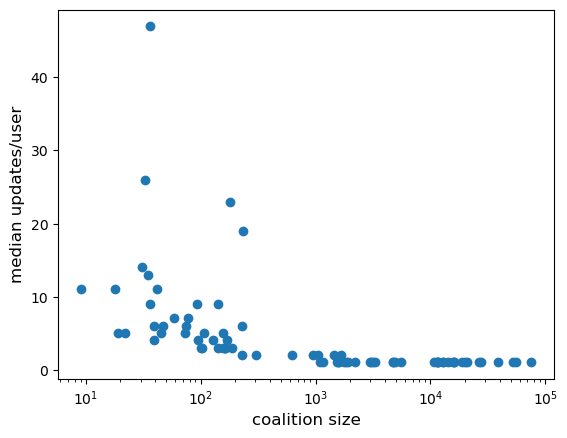

In [390]:
# Top 20
k = 20
res = list()
for i in range(0, 4):
    top_k =  sorted(size_med[i], key=lambda x: x[1], reverse=True)[:k]
    res = res + top_k
x = [i[0] for i in res]
y = [i[1] for i in res]
plt.scatter(x,y)
plt.xlabel('coalition size', size=12)
plt.ylabel('median updates/user',size=12)
plt.xscale('log')

## 2022

In [42]:
coal_med_update_22 = updates_coalition_median(user_update_22)
size_med_22 = dict()
brackets_22 = [100, 1000, 10000, 100000,1000000]

for key in coal_med_update_22:
    if key in a_user_22:
        size = a_user_22[key]
        med = coal_med_update_22[key]
        br = find_br(size, brackets_22)
        if br not in size_med_22:
            size_med_22[br] = [(size,med)]
        else:
            size_med_22[br].append((size,med))

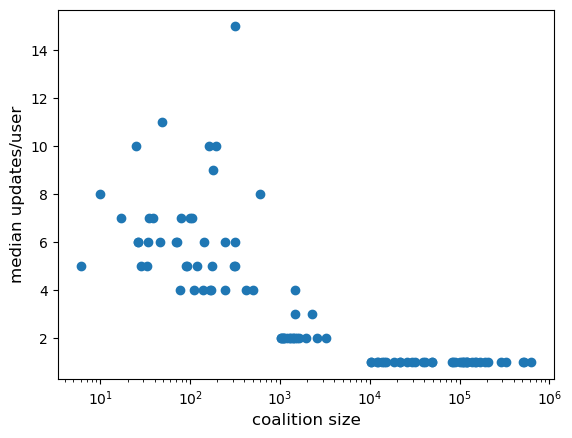

In [431]:
# Top 20
k = 20
res = list()
for i in range(0, 5):
    top_k =  sorted(size_med_22[i], key=lambda x: x[1], reverse=True)[:k]
    res = res + top_k
x = [i[0] for i in res]
y = [i[1] for i in res]
plt.scatter(x,y)
plt.xlabel('coalition size', size=12)
plt.ylabel('median updates/user',size=12)
plt.xscale('log')

## 2023

In [49]:
coal_med_update_23 = updates_coalition_median(user_update_23)
size_med_23 = dict()
brackets_23 = [100, 1000, 10000, 100000,1000000]

for key in coal_med_update_23:
    if key in a_user_23:
        size = a_user_23[key]
        med = coal_med_update_23[key]
        br = find_br(size, brackets_23)
        if br not in size_med_23:
            size_med_23[br] = [(size,med)]
        else:
            size_med_23[br].append((size,med))

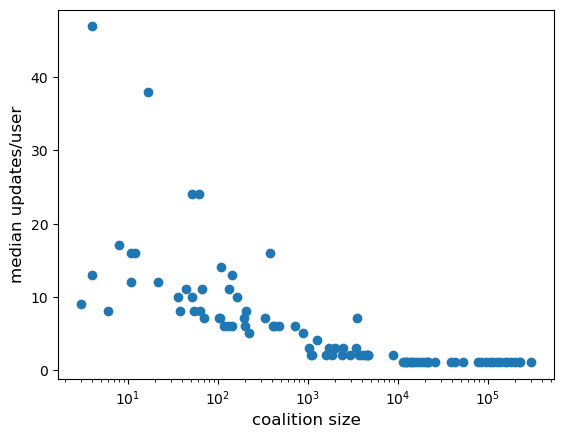

In [434]:
# Top 20
k = 20
res = list()
for i in range(0, 5):
    top_k =  sorted(size_med_23[i], key=lambda x: x[1], reverse=True)[:k]
    res = res + top_k
x = [i[0] for i in res]
y = [i[1] for i in res]
plt.scatter(x,y)
plt.xlabel('coalition size', size=12)
plt.ylabel('median updates/user',size=12)
plt.xscale('log')

# Updates/user vs Coalition Size each point is one user

# 2017

In [19]:
a_users_proj = agreeing_user_per_proj(input_file_proj_17)

In [20]:
user_coalition_17, user_update_17 = user_coalition_size_updates(input_file_proj_17, a_users_proj)

In [37]:
def plot_updates_per_user_icdf(count1, count2, count3,count4):
    plt.clf()
    plt.figure(figsize=(4,3))
    ax = plt.subplot(111)
    ax.loglog(range(len(count1)), count1, color="#fa4d56", marker = 'o', markevery=0.1, linewidth=2, label = r'$0<$ size $\leq 100$')
    ax.loglog(range(len(count2)), count2, color="#002d9c", marker = 'x', markevery = 0.1, linewidth=2, label = r'$100<$ size $\leq 1000$')
    ax.loglog(range(len(count3)), count3, color="k", linewidth=2, label = r'size$>1000$')
#     ax.loglog(range(len(count4)), count4, color="g", marker='o', linewidth=2, label = "(10000, 100000]")


    ax.set_ylabel('ICDF', fontsize=15)
    ax.set_xlabel('median actions/player', fontsize=15)
    ax.tick_params(labelsize=10)
    ax.set_xlim(1,100)
    ax.set_ylim(None,1)
    ax.legend(loc = 'upper right')
#     plt.savefig(output_file_name, dpi=300, bbox_inches='tight')

In [22]:
def icdf(lst):
    count = np.zeros(int(max(lst) + 1))
    for k in lst:
        k = int(k)
        count[k] = count[k] + 1
    for i in reversed(range(len(count)-1)):
        count[i] = count[i] + count[i+1]
    count = count / count[0]
    return count

In [33]:
dist_0 = [x[1] for x in size_med[0]]
dist_1 = [x[1] for x in size_med[1]]
dist_2 = [x[1] for x in size_med[2]]
dist_3 = [x[1] for x in size_med[3]]
dist_2 = dist_2 + dist_3
icdf_0 = icdf(dist_0)
icdf_1 = icdf(dist_1)
icdf_2 = icdf(dist_2)
# icdf_3 = icdf(dist_3)

## 2017

<Figure size 640x480 with 0 Axes>

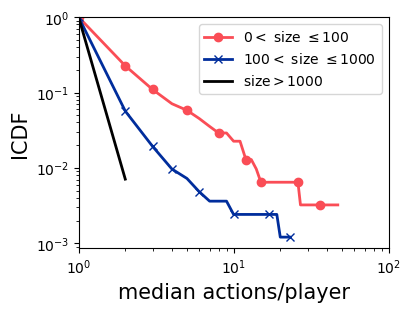

In [38]:
plot_updates_per_user_icdf(icdf_0,icdf_1,icdf_2,icdf_0)

## 2022

In [43]:
dist_0 = [x[1] for x in size_med_22[0]]
dist_1 = [x[1] for x in size_med_22[1]]
dist_2 = [x[1] for x in size_med_22[2]]
dist_3 = [x[1] for x in size_med_22[3]]
dist_4 = [x[1] for x in size_med_22[4]]
dist_2 = dist_2 + dist_3 + dist_4
icdf_0 = icdf(dist_0)
icdf_1 = icdf(dist_1)
icdf_2 = icdf(dist_2)
# icdf_3 = icdf(dist_3)
# icdf_4 = icdf(dist_4)

<Figure size 640x480 with 0 Axes>

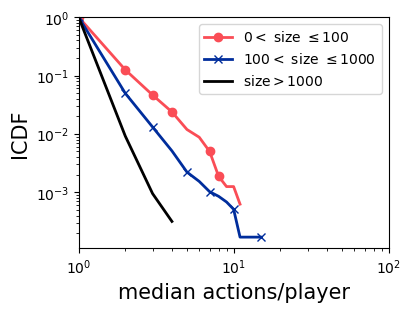

In [45]:
plot_updates_per_user_icdf(icdf_0,icdf_1,icdf_2,icdf_1)

<Figure size 640x480 with 0 Axes>

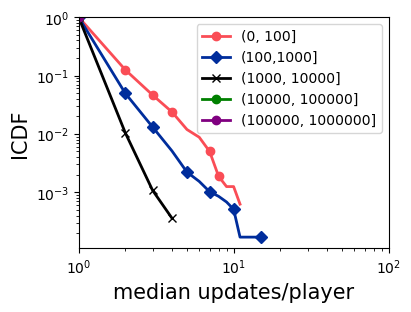

In [491]:
def plot_updates_per_user_icdf(count1, count2, count3,count4, count5):
    plt.clf()
    plt.figure(figsize=(4,3))
    ax = plt.subplot(111)
    ax.loglog(range(len(count1)), count1, color="#fa4d56", marker = 'o', markevery=0.1, linewidth=2, label = "(0, 100]")
    ax.loglog(range(len(count2)), count2, color="#002d9c", marker = 'D', markevery = 0.1, linewidth=2, label = "(100,1000]")
    ax.loglog(range(len(count3)), count3, color="k", marker = 'x', linewidth=2, label = "(1000, 10000]")
    ax.loglog(range(len(count4)), count4, color="g", marker = 'o', linewidth=2, label = "(10000, 100000]")
    ax.loglog(range(len(count5)), count5, color="purple", marker = 'o', linewidth=2, label = "(100000, 1000000]")
#     ax.loglog(range(len(count3)), count6, color="purple", linewidth=2, label = "(10000, 100000]")


    ax.set_ylabel('ICDF', fontsize=15)
    ax.set_xlabel('median updates/player', fontsize=15)
    ax.tick_params(labelsize=10)
    ax.set_xlim(1,100)
    ax.set_ylim(None,1)
    ax.legend(loc = 'upper right')
#     plt.savefig(output_file_name, dpi=300, bbox_inches='tight')
plot_updates_per_user_icdf(icdf_0,icdf_1,icdf_2,icdf_3,icdf_4)

## 2023

In [50]:
dist_0 = [x[1] for x in size_med_23[0]]
dist_1 = [x[1] for x in size_med_23[1]]
dist_2 = [x[1] for x in size_med_23[2]]
dist_3 = [x[1] for x in size_med_23[3]]
dist_4 = [x[1] for x in size_med_23[4]]
dist_2 = dist_2 + dist_3 + dist_4
icdf_0 = icdf(dist_0)
icdf_1 = icdf(dist_1)
icdf_2 = icdf(dist_2)
# icdf_3 = icdf(dist_3)
# icdf_4 = icdf(dist_4)

<Figure size 640x480 with 0 Axes>

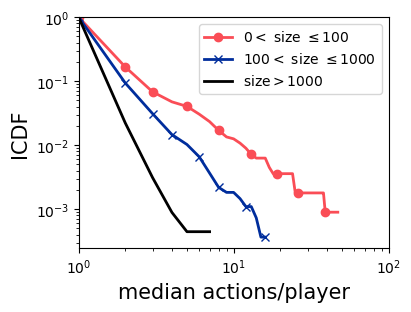

In [51]:
plot_updates_per_user_icdf(icdf_0,icdf_1,icdf_2,icdf_1)

In [378]:
x_axis = ["<100", "<1000", "<10000", "<100000"]
y = []
for i in range(0, 4):
    up_mean = np.mean(np.array(size_med[i])[:,1])
    y.append(up_mean)

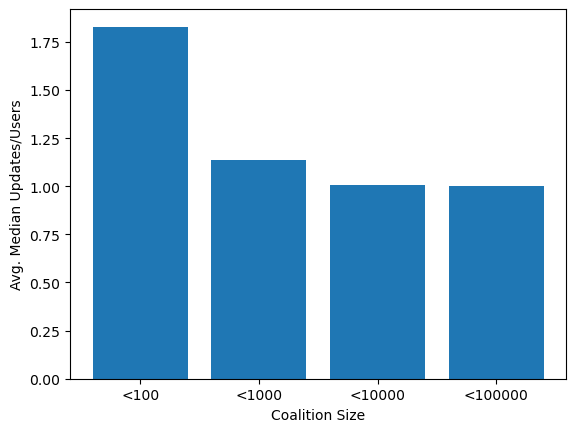

In [380]:
plt.bar(x_axis, y)  # Set width depending on spacing of x
plt.xlabel('Coalition Size')
plt.ylabel('Avg. Median Updates/Users')
plt.show()

In [407]:
def repeated_user(user_update):
    repeated_user = dict()
    for user, proj in user_update:
        if user not in repeated_user:
            repeated_user[user] = [(proj, user_update[(user,proj)])]
        else:
            repeated_user[user].append((proj, user_update[(user,proj)]))
    out = dict()
    for user in repeated_user:
        if len(repeated_user[user]) >= 2:
            out[user] = repeated_user[user]
    return out

In [408]:
re_user = repeated_user(user_update_17)

In [414]:
a_users_proj

{'1122': 75946,
 '4': 15841,
 '1038': 855,
 '230': 981,
 '154': 3159,
 '360': 27676,
 '1033': 1578,
 '206': 4759,
 '2': 20072,
 '1976': 3038,
 '58': 1835,
 '1031': 234,
 '692': 844,
 '118': 1762,
 '1': 5515,
 '1066': 51980,
 '1946': 2193,
 '133': 356,
 '1018': 4767,
 '1337': 1153,
 '2024': 4917,
 '286': 18979,
 '54': 2978,
 '1618': 1910,
 '1050': 1524,
 '1493': 3311,
 '137': 1597,
 '46': 26361,
 '110': 11716,
 '279': 1084,
 '437': 385,
 '115': 1747,
 '330': 627,
 '1715': 1943,
 '1975': 2457,
 '748': 48,
 '820': 278,
 '451': 1265,
 '1139': 12922,
 '1945': 231,
 '1919': 128,
 '212': 423,
 '390': 11629,
 '637': 12756,
 '199': 10727,
 '39': 4239,
 '87': 3768,
 '189': 1643,
 '73': 38701,
 '219': 1060,
 '135': 9007,
 '380': 4253,
 '71': 8170,
 '1747': 166,
 '1462': 601,
 '268': 4729,
 '122': 8031,
 '255': 2518,
 '1082': 208,
 '215': 2473,
 '357': 11332,
 '1303': 163,
 '75': 56187,
 '570': 34,
 '382': 2788,
 '1186': 1038,
 '12': 20942,
 '828': 2075,
 '1409': 229,
 '1030': 154,
 '1879': 166,
 

In [415]:
top_20 = sorted(re_user.items(), key=lambda item: len(item[1]), reverse=True)[:20]

# Convert back to dictionary (optional)
top_20_dict = dict(top_20)


In [416]:
X = list()
Y = list()
for key in top_20_dict:
    curr_X = list()
    curr_Y = list()
    for val in top_20_dict[key]:
        proj = val[0]
        up = val[1]
        curr_Y.append(up)
        size = a_users_proj[proj]
        curr_X.append(size)
    X.append(curr_X)
    Y.append(curr_Y)

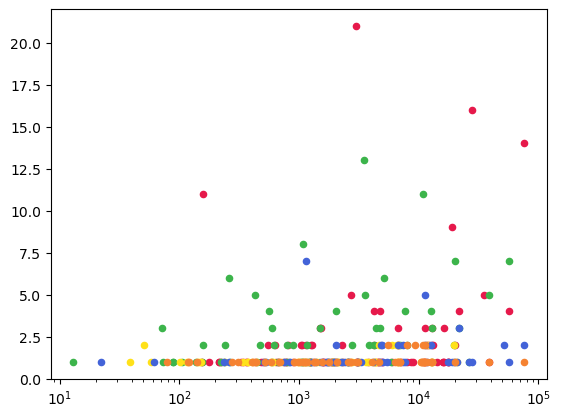

In [428]:
for i in range(0, 5):
    plt.scatter(X[i], Y[i], color = color_list[i],s=20)
plt.xscale('log')

In [422]:
len(Y[0])

92

In [413]:
color_list = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#ffffff']

In [290]:
X_17_user, Y_17_user = Create_Array(a_users_proj, coal_med_update_17)


<Figure size 640x480 with 0 Axes>

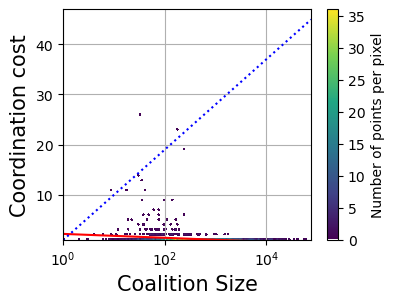

In [291]:
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

In [304]:

size_up, prob_1, prob_2, prob_3 = prob_coalition(user_update_17,a_users_proj)

In [340]:
size_up = box_plot_data(user_update_17,a_users_proj, 76000,20)

In [342]:
keys = sorted(size_up.keys())

In [343]:
d = [np.array(size_up[x]) for x in keys]

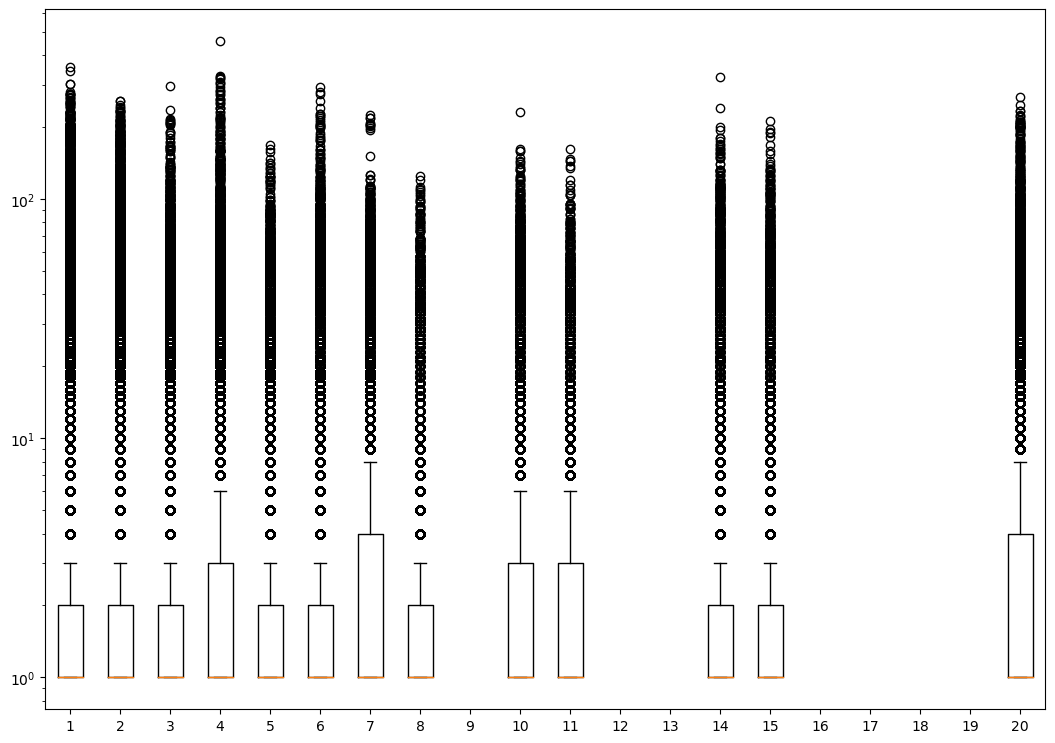

In [344]:
fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
bp = ax.boxplot(d, vert=True, showfliers=True)
plt.yscale('log')
plt.show()

In [327]:
np.arange(0, 76000, int(76000/10))

array([    0,  7600, 15200, 22800, 30400, 38000, 45600, 53200, 60800,
       68400])

In [305]:
X = []
Y = []
for key in prob_3:
    for val in prob_3[key]:
        X.append(key)
        Y.append(val)

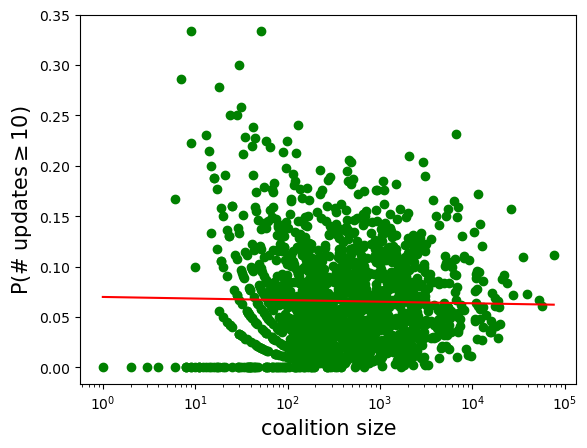

In [311]:
log_X = np.log(X)
coeffs = np.polyfit(log_X, Y, deg=1)
line_fit = np.poly1d(coeffs)

# Generate smooth x values for the line
X_fit = np.logspace(np.log10(min(X)), np.log10(max(X)), 100)
Y_fit = line_fit(np.log(X_fit))
plt.plot(X_fit, Y_fit, color='red')

plt.scatter(X, Y, c= 'g')

plt.ylabel(r'P(# updates$\geq10$)', fontsize=15)
#ax.tick_params(labelsize=10)
# plt.legend(loc = 'upper left')
plt.xlabel('coalition size', fontsize=15)
plt.xscale('log')

Text(0.5, 0, 'coalition size')

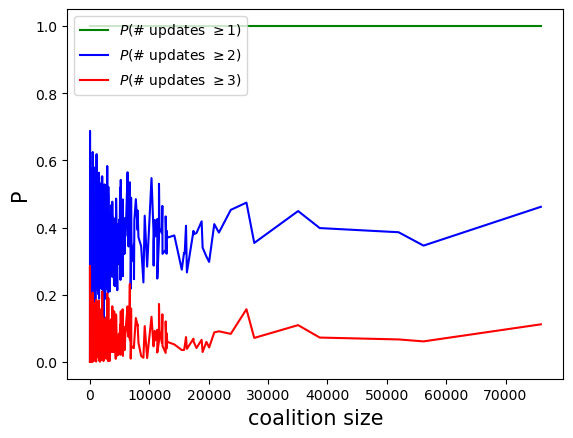

In [249]:
X = sorted(prob_1.keys())
prob_1_Y = [prob_1[key] for key in X] 
prob_2_Y = [prob_2[key] for key in X]
prob_3_Y = [prob_3[key] for key in X]

# Plot the best-fit line only
plt.plot(X, prob_1_Y, c= 'g', label = r'$P$(# updates $\geq 1$)')
plt.plot(X, prob_2_Y, c = 'b',label = r'$P$(# updates $\geq 2$)')
plt.plot(X, prob_3_Y, c = 'r',label = r'$P$(# updates $\geq 3$)')
plt.ylabel('P', fontsize=15)
#ax.tick_params(labelsize=10)
plt.legend(loc = 'upper left')
plt.xlabel('coalition size', fontsize=15)
# plt.xscale('log')

Text(0.5, 0, 'coalition size')

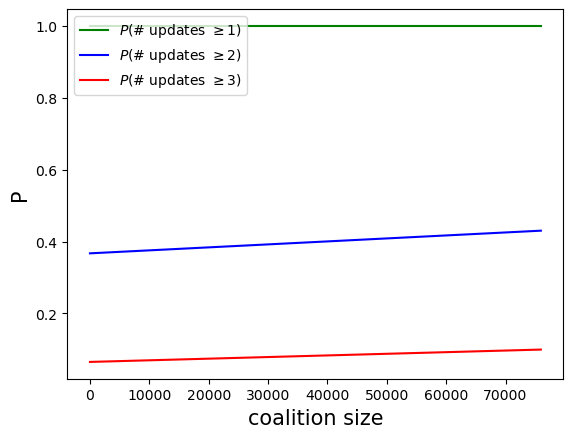

In [248]:
X = sorted(prob_1.keys())
prob_1_Y = [prob_1[key] for key in X] 
prob_2_Y = [prob_2[key] for key in X]
prob_3_Y = [prob_3[key] for key in X]

coeffs = np.polyfit(X, prob_1_Y, deg=1)
m, b = coeffs
x_fit = np.linspace(min(X), max(X), 100)
y_fit_1 = m * x_fit + b

coeffs = np.polyfit(X, prob_2_Y, deg=1)
m, b = coeffs
y_fit_2 = m * x_fit + b

coeffs = np.polyfit(X, prob_3_Y, deg=1)
m, b = coeffs
y_fit_3 = m * x_fit + b

# Plot the best-fit line only
plt.plot(x_fit, y_fit_1, c= 'g', label = r'$P$(# updates $\geq 1$)')
plt.plot(x_fit, y_fit_2, c = 'b',label = r'$P$(# updates $\geq 2$)')
plt.plot(x_fit, y_fit_3, c = 'r',label = r'$P$(# updates $\geq 3$)')
plt.ylabel('P', fontsize=15)
#ax.tick_params(labelsize=10)
plt.legend(loc = 'upper left')
plt.xlabel('coalition size', fontsize=15)
# plt.xscale('log')

## 2022

In [240]:
size_up_22, prob_1_22, prob_2_22, prob_3_22 = prob_coalition(user_update_22,a_user_22)

Text(0.5, 0, 'coalition size')

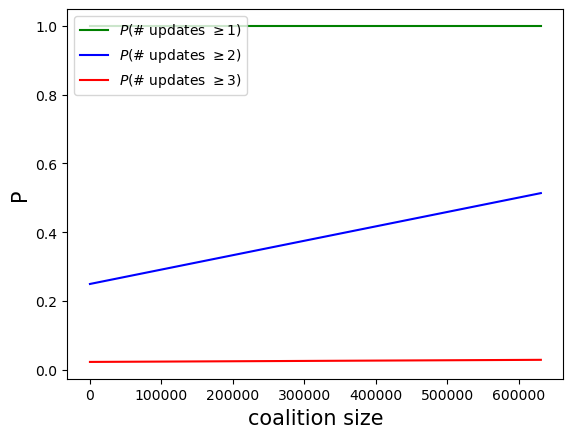

In [241]:
X = sorted(prob_1_22.keys())
prob_1_Y = [prob_1_22[key] for key in X] 
prob_2_Y = [prob_2_22[key] for key in X]
prob_3_Y = [prob_3_22[key] for key in X]

coeffs = np.polyfit(X, prob_1_Y, deg=1)
m, b = coeffs
x_fit = np.linspace(min(X), max(X), 100)
y_fit_1 = m * x_fit + b

coeffs = np.polyfit(X, prob_2_Y, deg=1)
m, b = coeffs
y_fit_2 = m * x_fit + b

coeffs = np.polyfit(X, prob_3_Y, deg=1)
m, b = coeffs
y_fit_3 = m * x_fit + b

# Plot the best-fit line only
plt.plot(x_fit, y_fit_1, c= 'g', label = r'$P$(# updates $\geq 1$)')
plt.plot(x_fit, y_fit_2, c = 'b',label = r'$P$(# updates $\geq 2$)')
plt.plot(x_fit, y_fit_3, c = 'r',label = r'$P$(# updates $\geq 3$)')
plt.ylabel('P', fontsize=15)
#ax.tick_params(labelsize=10)
plt.legend(loc = 'upper left')
plt.xlabel('coalition size', fontsize=15)
# plt.xscale('log')

Text(0.5, 0, 'coalition size')

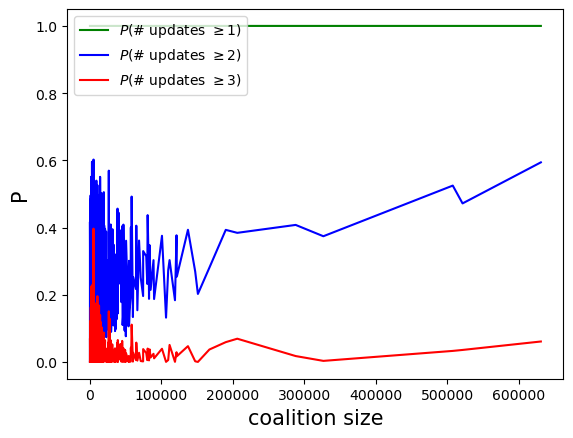

In [242]:
X = sorted(prob_1_22.keys())
prob_1_Y = [prob_1_22[key] for key in X] 
prob_2_Y = [prob_2_22[key] for key in X]
prob_3_Y = [prob_3_22[key] for key in X]

# Plot the best-fit line only
plt.plot(X, prob_1_Y, c= 'g', label = r'$P$(# updates $\geq 1$)')
plt.plot(X, prob_2_Y, c = 'b',label = r'$P$(# updates $\geq 2$)')
plt.plot(X, prob_3_Y, c = 'r',label = r'$P$(# updates $\geq 3$)')
plt.ylabel('P', fontsize=15)
#ax.tick_params(labelsize=10)
plt.legend(loc = 'upper left')
plt.xlabel('coalition size', fontsize=15)
# plt.xscale('log')

## 2023

In [243]:
size_up_23, prob_1_23, prob_2_23, prob_3_23 = prob_coalition(user_update_23,a_user_23)

Text(0.5, 0, 'coalition size')

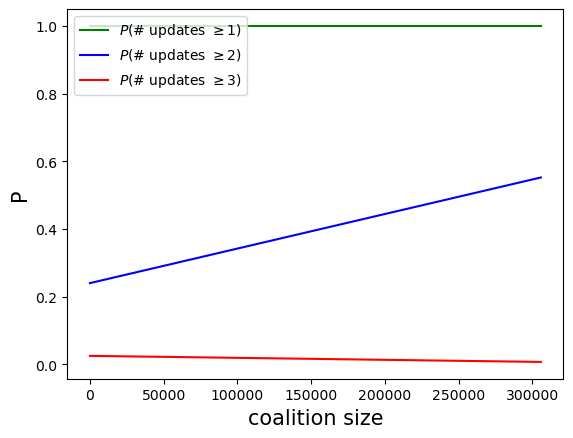

In [244]:
X = sorted(prob_1_23.keys())
prob_1_Y = [prob_1_23[key] for key in X] 
prob_2_Y = [prob_2_23[key] for key in X]
prob_3_Y = [prob_3_23[key] for key in X]

coeffs = np.polyfit(X, prob_1_Y, deg=1)
m, b = coeffs
x_fit = np.linspace(min(X), max(X), 100)
y_fit_1 = m * x_fit + b

coeffs = np.polyfit(X, prob_2_Y, deg=1)
m, b = coeffs
y_fit_2 = m * x_fit + b

coeffs = np.polyfit(X, prob_3_Y, deg=1)
m, b = coeffs
y_fit_3 = m * x_fit + b

# Plot the best-fit line only
plt.plot(x_fit, y_fit_1, c= 'g', label = r'$P$(# updates $\geq 1$)')
plt.plot(x_fit, y_fit_2, c = 'b',label = r'$P$(# updates $\geq 2$)')
plt.plot(x_fit, y_fit_3, c = 'r',label = r'$P$(# updates $\geq 3$)')
plt.ylabel('P', fontsize=15)
#ax.tick_params(labelsize=10)
plt.legend(loc = 'upper left')
plt.xlabel('coalition size', fontsize=15)
# plt.xscale('log')

Text(0.5, 0, 'coalition size')

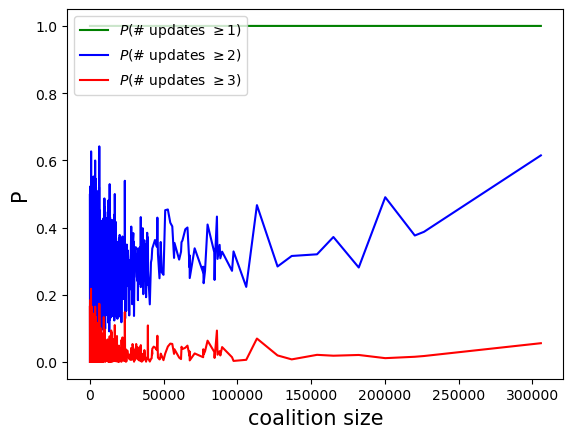

In [245]:
X = sorted(prob_1_23.keys())
prob_1_Y = [prob_1_23[key] for key in X] 
prob_2_Y = [prob_2_23[key] for key in X]
prob_3_Y = [prob_3_23[key] for key in X]

# Plot the best-fit line only
plt.plot(X, prob_1_Y, c= 'g', label = r'$P$(# updates $\geq 1$)')
plt.plot(X, prob_2_Y, c = 'b',label = r'$P$(# updates $\geq 2$)')
plt.plot(X, prob_3_Y, c = 'r',label = r'$P$(# updates $\geq 3$)')
plt.ylabel('P', fontsize=15)
#ax.tick_params(labelsize=10)
plt.legend(loc = 'upper left')
plt.xlabel('coalition size', fontsize=15)
# plt.xscale('log')

In [117]:
X_17_user, Y_17_user = Create_Array(user_coalition_17, user_update_17)


0.015828983584135585

<Figure size 640x480 with 0 Axes>

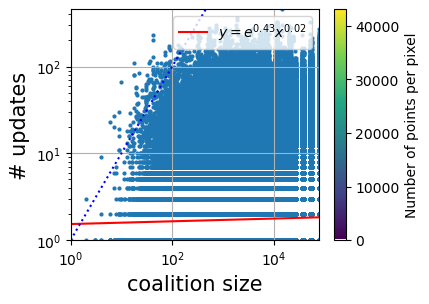

In [123]:
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

## 2022

In [40]:
user_coalition_22, user_update_22 = user_coalition_size_updates(input_file_proj_22, a_user_22)
coal_med_update_22 = updates_coalition_median(user_update_22)

-0.02210391579470322

<Figure size 640x480 with 0 Axes>

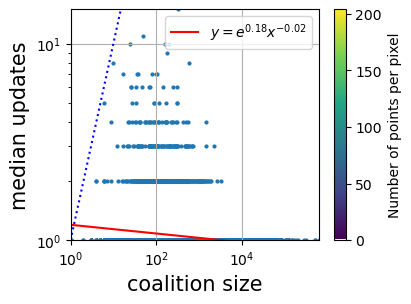

In [130]:
X_17_user, Y_17_user = Create_Array(a_user_22, coal_med_update_22)
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

## 2023

In [48]:
user_coalition_23, user_update_23 = user_coalition_size_updates(input_file_proj_23, a_user_23)
coal_med_update_23 = updates_coalition_median(user_update_23)

In [161]:
user_coalition_23

{('no+8HEIDjbdx7/LxH9Xr+h4lyoar0MRTYugWKrGdQOg7dFg0rU9STehlIqsje1kc48U/BQqB/0J8sHQzXJBDFA==',
  '68'): 20645,
 ('a6Q+OsCSRDcPxhxYtOsWmY1eROZ5FGYODL3sN5AWaIrPPH/nba0dvtbBcRp4yRr8yRazx96fK472L390bfYkRA==',
  '581'): 4645,
 ('vFCy3asEWbBER9NYcILtUCB+KYxRWIGMaO92JTha0185vZb/n8jKzkjdomCu6+UXXXsTgckeGIouNG3mivHaqg==',
  '1026'): 626,
 ('sxYEVPfaohJYIYvTq4Bv89Ai8TPHe/bCrreUQSH/u7+9lhqLRSo6oRuuFHCt4IKy1ltsLU4hEM0tRLPb66tA7w==',
  '25'): 12052,
 ('hFtqzlOnL9uziNezzvlcJBxc8npCRS6Fhb0HaM5HmS4sDru6t1RP7+wWZmt3yppUKEQyASoUbtcrDD6L8qXIxQ==',
  '1558'): 2330,
 ('elaAZQ+EuWCc2r6PgWndyUP+spRSGqIcClghWw1uxIfZUtkh3Y8DmXGMPylq8t5Nf1b/RFHnRP/aZYVVwWGFTg==',
  '123'): 3741,
 ('8VLRxlOul/0Yr46R8uAiJ7YScVI8Yq4+FerMn8mY5DuGEHGIAgNTBPAkw/TYWpA/fjv5Cg2l7pxuKOJITtHT7A==',
  '371'): 25942,
 ('VwROKxPV4+9TJEUDRlriTNYqk/I4QkDONi3iAHAClzsj2vWnh8ZDPpqDUSHMvFO1aXpKVmRUiivFvO70kAswmg==',
  '1743'): 2658,
 ('kVFA3icUYz7O+souayxnVowXXnEL7pVg/uwRtkN62D84JjqknlSCzuBCXHt5HnUZaJDBirz04yIJ+Hgzyt9qEQ==',
  '176'): 9008,
 ('np2A

-0.03457675317344408

<Figure size 640x480 with 0 Axes>

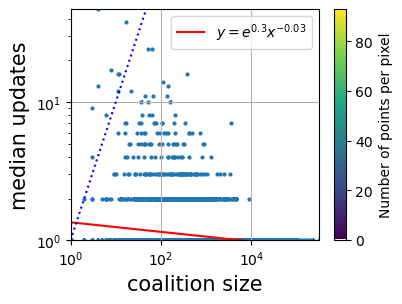

In [135]:
X_17_user, Y_17_user = Create_Array(a_user_23, coal_med_update_23)
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

# Updates/user vs Coalition Size

# 2017

1.0100622856907426

<Figure size 640x480 with 0 Axes>

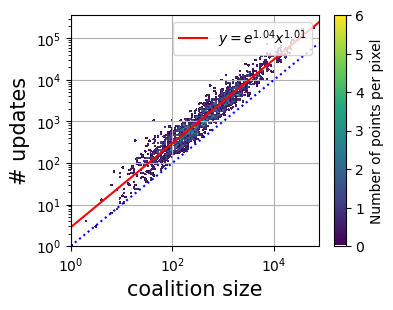

In [34]:
X_17_user, Y_17_user = Create_Array(a_users_proj, a_up_proj)
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

0.010062285690742571

<Figure size 640x480 with 0 Axes>

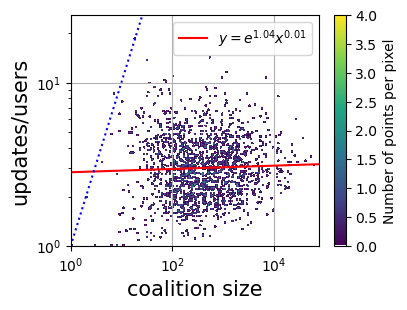

In [73]:
updates_per_user_proj_17 = dict()
for key in a_up_proj:
    updates_per_user_proj_17[key] = a_up_proj[key] / a_users_proj[key]
X_17_user, Y_17_user = Create_Array(a_users_proj, updates_per_user_proj_17)
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

# 2022

In [30]:

a_user_22 = agreeing_user_per_proj(input_file_proj_22)
a_up_proj_22 = agreeing_updates_proj(input_file_proj_22)



In [28]:
updates_per_user_proj_22 = dict()
for key in a_up_proj_22:
    updates_per_user_proj_22[key] = a_up_proj_22[key] / a_user_22[key]

0.9865804223142098

<Figure size 640x480 with 0 Axes>

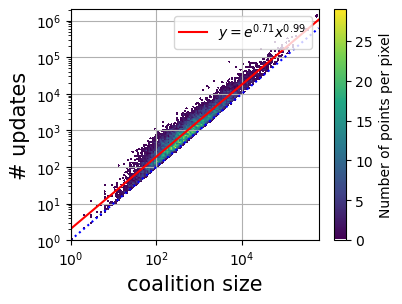

In [38]:
X_22_user, Y_22_user = Create_Array(a_user_22, a_up_proj_22)
plot_updates_vs_pixels(X_22_user, Y_22_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

In [ ]:
updates_per_user_proj_22 = dict()
for key in a_up_proj_22:
    updates_per_user_proj_22[key] = a_up_proj_22[key] / a_user_22[key]

-0.013419577685790506

<Figure size 640x480 with 0 Axes>

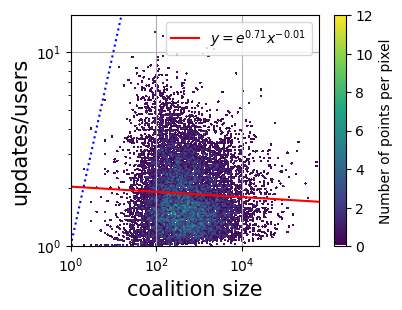

In [74]:
X_22_user, Y_22_user = Create_Array(a_user_22, updates_per_user_proj_22)
plot_updates_vs_pixels(X_22_user, Y_22_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

# 2023

In [31]:
input_file_proj_23 = "/home/yw180/place/data_2023/sorted_tile_placements_proj.csv"
a_user_23 = agreeing_user_per_proj(input_file_proj_23)
# a_up_proj_23 = agreeing_updates_proj(input_file_proj_23)



0.9563042142229199

<Figure size 640x480 with 0 Axes>

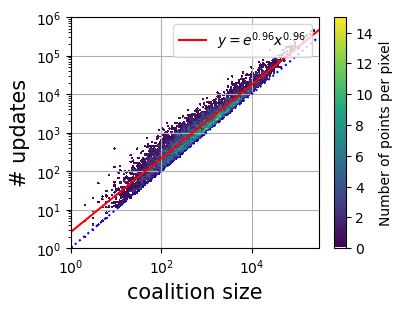

In [36]:
X_23_user, Y_23_user = Create_Array(a_user_23, a_up_proj_23)
plot_updates_vs_pixels(X_23_user, Y_23_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

-0.04369578577708032

<Figure size 640x480 with 0 Axes>

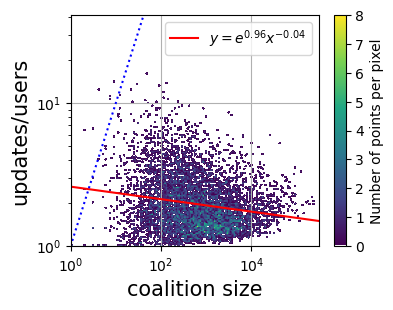

In [76]:
updates_per_user_proj_23 = dict()
for key in a_up_proj_23:
    updates_per_user_proj_23[key] = a_up_proj_23[key] / a_user_23[key]
X_23_user, Y_23_user = Create_Array(a_user_23, updates_per_user_proj_23)
plot_updates_vs_pixels(X_23_user, Y_23_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

# 2017

0.9393296115972742

<Figure size 640x480 with 0 Axes>

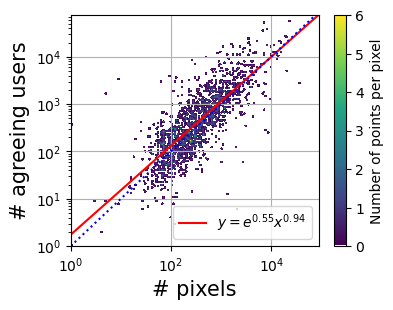

In [266]:
X_17_user, Y_17_user = Create_Array(pixels_proj_17, a_users_proj)
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

In [263]:
input_file_proj_22 = "/home/yw180/place/data_2022/sorted_tile_placements_proj.csv"

# label_22, color_22 = build_final_label(input_file_proj_22, 2001, 2001)
project_to_remove = {}
# Computing number of pixels per project
#Only pixels (final) are considered.
pixels_proj_22 = pixels_per_project(input_file_proj_22, project_to_remove)
# pixels_proj_17 = {int(key): val for key, val in pixels_proj_17.items()}
a_user_22 = agreeing_user_per_proj(input_file_proj_22)


# 2022

0.8087901227609027

<Figure size 640x480 with 0 Axes>

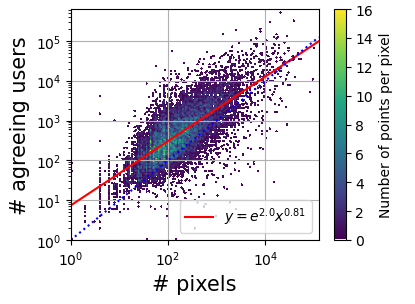

In [267]:
X_22_user, Y_22_user = Create_Array(pixels_proj_22, a_user_22)
plot_updates_vs_pixels(X_22_user, Y_22_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

In [155]:
input_file_proj_23 = "/home/yw180/place/data_2023/sorted_tile_placements_proj.csv"
project_to_remove = {}
# Computing number of pixels per project
#Only pixels (final) are considered.
# pixels_proj_23 = pixels_per_project(input_file_proj_23, project_to_remove)
# pixels_proj_17 = {int(key): val for key, val in pixels_proj_17.items()}
a_user_23 = agreeing_user_per_proj(input_file_proj_23)


# 2023

0.8481694210077115

<Figure size 640x480 with 0 Axes>

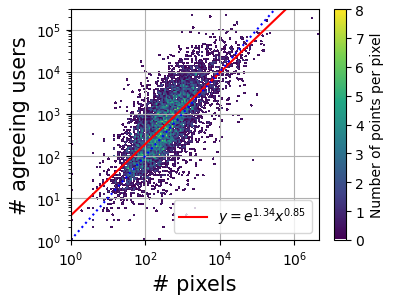

In [269]:
X_23_user, Y_23_user = Create_Array(pixels_proj_23, a_user_23)
plot_updates_vs_pixels(X_23_user, Y_23_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

# User vs pixel on final canvas, 2017

In [227]:
X_17_user, Y_17_user = Create_Array(pixels_proj_17, users_proj_17)

0.9701531898145124

<Figure size 640x480 with 0 Axes>

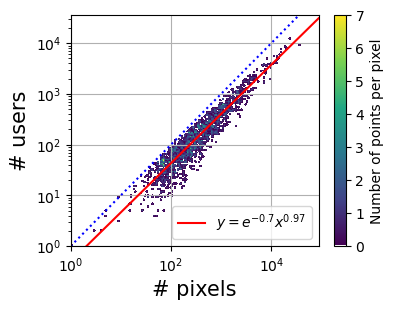

In [228]:
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

In [137]:
np.log10(1)

0.0

# 2022

In [231]:
input_file_proj_22 = "/home/yw180/place/data_2022/sorted_tile_placements_proj.csv"
project_to_remove = {}
# Computing number of pixels per project
#Only pixels (final) are considered.
pixels_proj_22 = pixels_per_project(input_file_proj_22, project_to_remove)
# pixels_proj_17 = {int(key): val for key, val in pixels_proj_17.items()}
users_proj_22 = user_per_project_on_final(input_file_proj_22)


0.9388543242499774

<Figure size 640x480 with 0 Axes>

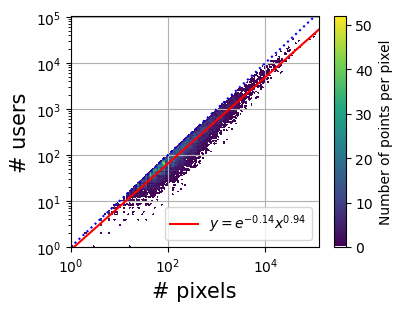

In [232]:
X_17_user, Y_17_user = Create_Array(pixels_proj_22, users_proj_22)
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

# 2023

In [154]:
input_file_proj_23 = "/home/yw180/place/data_2023/sorted_tile_placements_proj.csv"
project_to_remove = {}
# Computing number of pixels per project
#Only pixels (final) are considered.
pixels_proj_23 = pixels_per_project(input_file_proj_23, project_to_remove)
# pixels_proj_17 = {int(key): val for key, val in pixels_proj_17.items()}
users_proj_23 = user_per_project_on_final(input_file_proj_23)


0.9675285652525251

<Figure size 640x480 with 0 Axes>

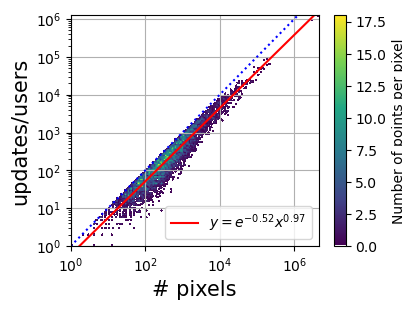

In [155]:
X_17_user, Y_17_user = Create_Array(pixels_proj_23, users_proj_23)
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

# Coordination cost, repetitive updates (update that is the same color as last update), normalized by total agreeing updates

In [44]:
def calculate_coordination_cost(color_canv, input_file_proj, year):
    curr_canv = np.array(-1 * np.ones((len(color_canv), len(color_canv[0]))), dtype='str')
    proj_cost = dict()
    proj_total = dict()
    proj_proportion = dict()
    with open(input_file_proj,'r') as file:
        # Skip first line (header row)
        next(file, None)
        reader = csv.reader(file)

        for r in reader:
            #ts,user,x_coordinate,y_coordinate,color,pic_id,pixel,pixel_color
            if year == 2017:
                t = int(r[0]) / 1000
            else:
                t = int(r[0])
            proj = r[5]
            user = r[1]
            x = int(r[2])
            y = int(r[3])
            color = r[4]
            smallest = int(r[8])
            if not smallest:
                continue
            prev_color = curr_canv[y,x]
            curr_canv[y,x] = color
            final_color = color_canv[y,x]
            if color == final_color and proj not in proj_cost:
                proj_cost[proj] = 0
                proj_total[proj] = 0
            if color == final_color:
                proj_total[proj] += 1
                if color == prev_color:
                    proj_cost[proj] += 1
    for proj in proj_cost:
        proj_proportion[proj] = proj_cost[proj] / proj_total[proj]
    # return coordination cost, cost, total agreeing updates
    # coordination = cost / total agreeing updates
    return proj_proportion, proj_cost, proj_total

In [513]:
label_17, color_17 = build_final_label(input_file_proj_17, 1001, 1001)

max_x 1000
max_y 1000
min_x 0
min_y 0


In [514]:
end_time_17 = 1491238734
proj_proportion, proj_cost_17, proj_total_17 = calculate_coordination_cost(color_17, input_file_proj_17, 2017)

In [214]:
print(proj_proportion['1976'])
print(proj_cost_17['1976'])
print(proj_total_17['1976'])

0.3930757863626768
1862
4737


In [515]:
X_17_user, Y_17_user = Create_Array(a_users_proj, proj_proportion)


In [507]:
from matplotlib.ticker import ScalarFormatter
#Inverse cumulative density funcition

%matplotlib inline

def plot_updates_vs_pixels(X, Y, output_file_name, col, lab):
    white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)
#    xy = np.vstack([X,Y])
#    z = gaussian_kde(xy)(xy)
#    idx = z.argsort()
#    x, y, z = X[idx], Y[idx], z[idx]
    plt.clf()
    fig = plt.figure(figsize=(4,3))
    ax = plt.subplot(111,projection='scatter_density')    
    density = ax.scatter_density(X, Y, cmap=white_viridis, dpi=60)
    fig.colorbar(density, label='Number of points per pixel')
    logx = np.log(X)
    coeffs = np.polyfit(logx,Y,1)
    poly = np.poly1d(coeffs)
    yfit = lambda X: np.exp(poly(np.log(X)))
#     la = r"$y = e^{%s} x^{%s}$" % (round(coeffs[1],2), round(coeffs[0], 2))
#     plt.plot(np.unique(X),yfit(np.unique(X)), color='red') 
    coeffs = np.polyfit(logx, Y, 1)
    poly = np.poly1d(coeffs)
    y_pred = poly(logx)
    plt.plot(X, y_pred, color='red')

    ax.axline((1, 1),  (10, 10), color="blue", linestyle=":")
#     plt.scatter(X, Y, s=5)
    ax.set_ylabel('coordination cost', fontsize=15)
    #ax.tick_params(labelsize=10)
    ax.set_xlabel('coalition size', fontsize=15)
    ax.set_xscale('log')
#     ax.set_yscale('log')
#     ax.set_xlim([1,10**7])
#     ax.set_ylim([1,10**2])
#     ax.set_xticks(logx)
#     ax.set_aspect('equal', 'box')
#     ax.legend(loc = 'lower right')
    ax.grid()
#     plt.axis('square')
    
#     plt.savefig(output_file_name, dpi=300, bbox_inches='tight')
#     return coeffs[0]


<Figure size 640x480 with 0 Axes>

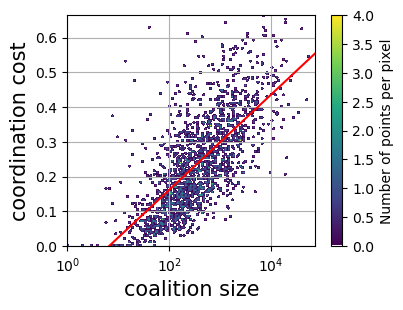

In [516]:
plot_updates_vs_pixels(X_17_user, Y_17_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

In [502]:
label_22, color_22 = build_final_label(input_file_proj_22, 2000, 2000)

max_x 1999
max_y 1999
min_x 0
min_y 0


In [503]:
proj_proportion, proj_cost_17, proj_total_17 = calculate_coordination_cost(color_22, input_file_proj_22, 2022)

<Figure size 640x480 with 0 Axes>

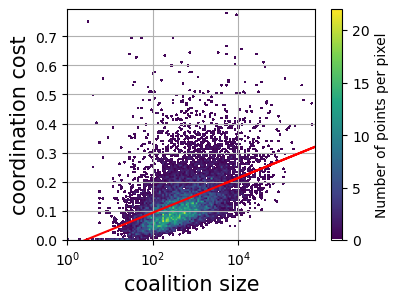

In [510]:
X_22_user, Y_22_user = Create_Array(a_user_22, proj_proportion)
plot_updates_vs_pixels(X_22_user, Y_22_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")

In [505]:
label_23, color_23 = build_final_label(input_file_proj_23, 3000, 2000)
proj_proportion_23, proj_cost_23, proj_total_23 = calculate_coordination_cost(color_23, input_file_proj_23, 2023)

max_x 2999
max_y 1999
min_x 0
min_y 0


<Figure size 640x480 with 0 Axes>

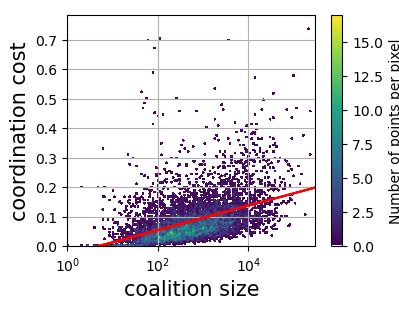

In [511]:
X_23_user, Y_23_user = Create_Array(a_user_23, proj_proportion_23)
plot_updates_vs_pixels(X_23_user, Y_23_user,"../plots/plot_updates_vs_pixels.svg", "#fa4d56", "2017")